1. Import libraries
2. Load dataset
3. Understand dataset
4. Clean data
5. EDA
6. Understand target & features
7. Encode categorical variables
8. Check correlations
9. Train-test split
10. Build OLS model
11. View coefficients
12. Interpret coefficients
13. Make predictions
14. Evaluate model
15. Actual vs Predicted
16. Residual calculation
17. Residual distribution
18. Residual vs predicted plot
19. Q-Q plot
20. Normality test
21. Homoscedasticity test
22. Multicollinearity / VIF
23. Outlier & influence analysis
24. Hypothesis testing
25. Confidence intervals
26. Overall F-test
27. Compare OLS with regularized models
28. Improve model if necessary
29. Final model conclusion

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

In [35]:
df = pd.read_csv(r"D:\practice files\insurance.csv")

In [36]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [37]:
df.shape

(1338, 7)

In [38]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [41]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [42]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(1)

In [44]:
df = df.drop_duplicates()

In [45]:
y = df["charges"]

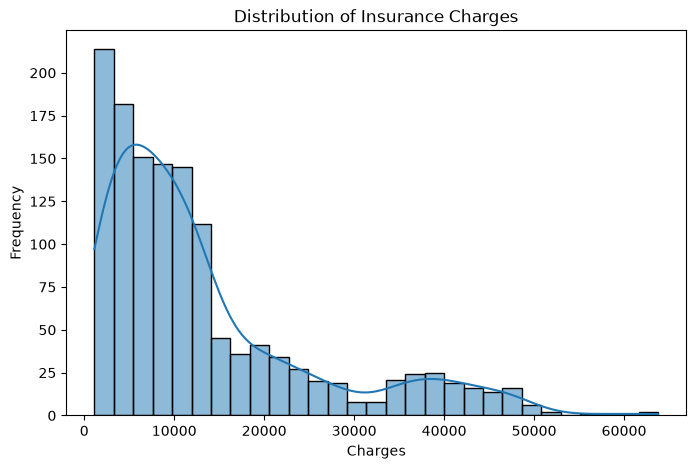

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(df["charges"], kde=True)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

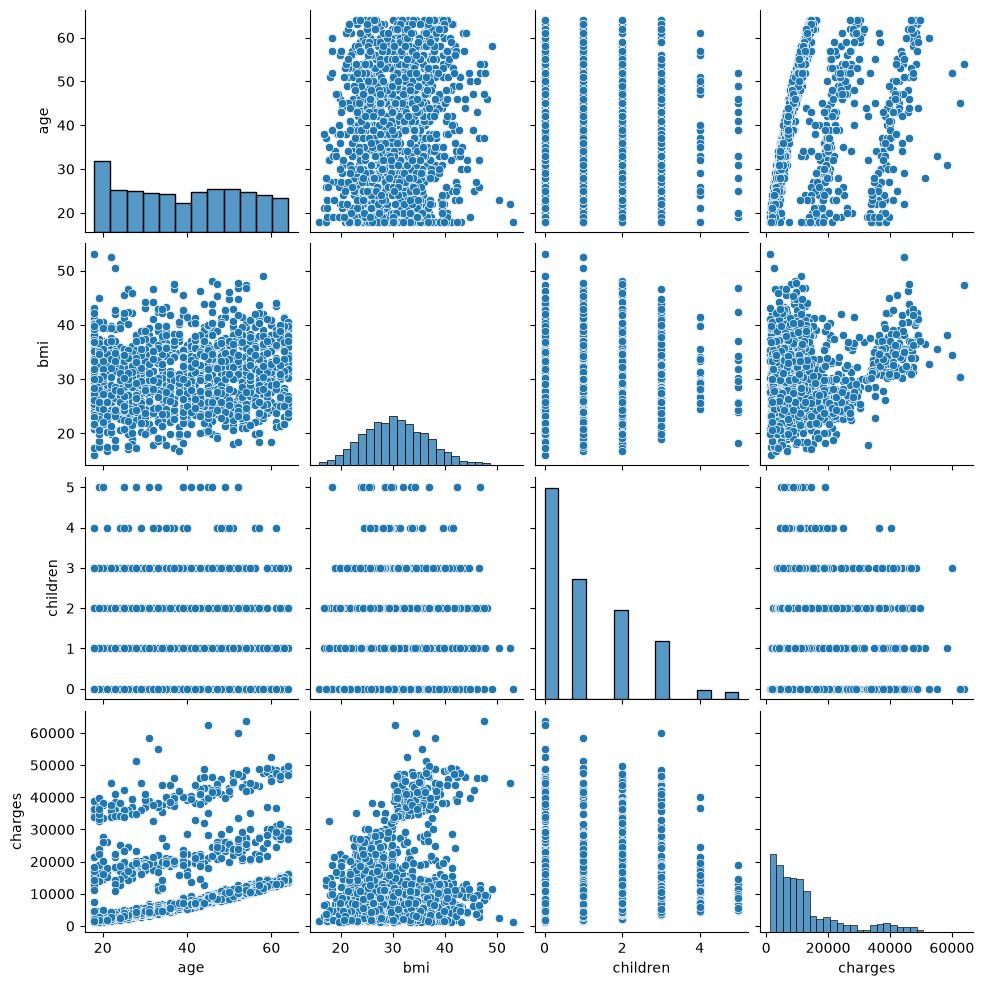

In [48]:
sns.pairplot(
    df[["age", "bmi", "children", "charges"]]
)

plt.show()

In [49]:
df_encoded = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

In [50]:
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


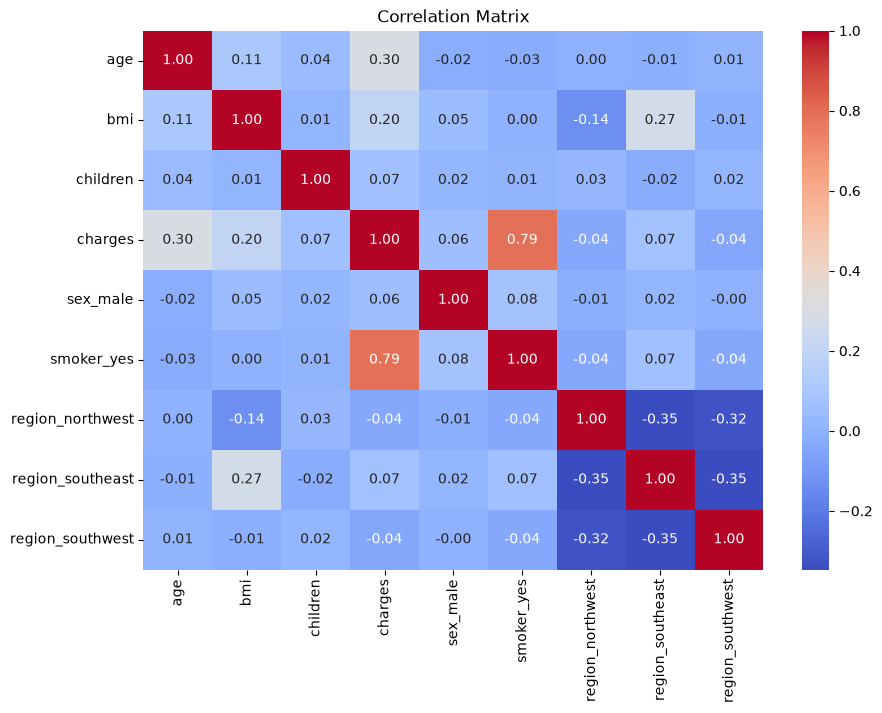

In [51]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [52]:
X = df_encoded.drop("charges", axis=1)

y = df_encoded["charges"]

In [53]:
X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0


In [54]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

# Train/test split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Add Intercept

In [56]:
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# build the ols model

In [57]:
ols_model = sm.OLS(
    y_train,
    X_train_sm
)

ols_results = ols_model.fit()

# OLS summary

In [58]:
print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     358.1
Date:                Sun, 09 Aug 2026   Prob (F-statistic):          4.94e-295
Time:                        11:52:52   Log-Likelihood:                -10831.
No. Observations:                1069   AIC:                         2.168e+04
Df Residuals:                    1060   BIC:                         2.172e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.109e+04   1114.260  

In [59]:
ols_results.params

const              -11092.652296
age                   248.210720
bmi                   318.701441
children              533.009989
sex_male             -101.542054
smoker_yes          23077.764593
region_northwest     -391.761455
region_southeast     -838.919616
region_southwest     -659.139752
dtype: float64

In [60]:
ols_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     358.1
Date:                Sun, 09 Aug 2026   Prob (F-statistic):          4.94e-295
Time:                        11:55:48   Log-Likelihood:                -10831.
No. Observations:                1069   AIC:                         2.168e+04
Df Residuals:                    1060   BIC:                         2.172e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.109e+04   1114.260     -9.955      0.000   -1.33e+04   -8906.246
age                248.2107     13.507     18.376      0.000     221.707     274.715
bmi                318.7014     32.543      9.793      0.000     254.845     382.558
children           533.0100    156.796      3.399      0.001     225.344     840.676
sex_male          -101.5421    375.787     -0.270      0.787    -838.914     635.829
smoker_yes        2.308e+04    471.030     48.994      0.000    2.22e+04     2.4e+04
region_northwest  -391.7615    537.999     -0.728      0.467   -1447.426     663.903
region_southeast  -838.9196    546.101     -1.536      0.125   -1910.481     232.641
region_southwest  -659.1398    539.459     -1.222      0.222   -1717.668     399.388
==============================================================================
Omnibus:                      266.561   Durbin-Watson:                   1.966
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              642.069
Skew:                           1.330   Prob(JB):                    3.77e-140
Kurtosis:                       5.710   Cond. No.                         311.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Make prediction

In [61]:
y_pred = ols_results.predict(X_test_sm)

# evaluation

In [63]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)              # Mean Absolute Error

MAE: 4177.045561036318


In [64]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 35478020.67523559


In [65]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)             # Root Mean Squared Error

RMSE: 5956.342894363587


In [66]:
r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.8069287081198012


In [67]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

metrics

,Metric,Value
0,MAE,4177.045561
1,RMSE,5956.342894
2,R²,0.806929


### Model Evaluation Metrics

- **MAE = 4177.05**  
  On average, the model’s predictions are off by about **4177**.  
  Lower is better.

- **RMSE = 5956.34**  
  This also measures error, but it gives more importance to big mistakes.  
  Since RMSE is higher than MAE, the model has some larger errors.

- **R² = 0.8069**  
  The model explains about **80.7%** of the variation in the target value.  
  This is a good score, but the model is not perfect.

# Actual vs Predicted Plot

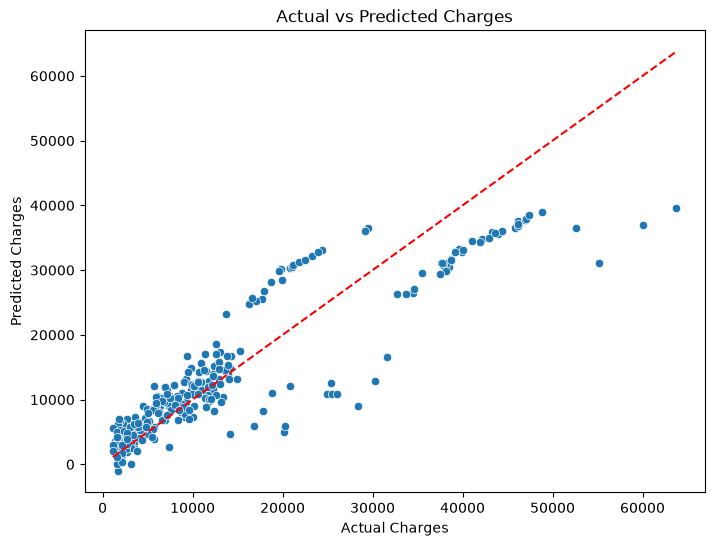

In [68]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.show()

In [69]:
residuals = y_test - y_pred

In [72]:
residuals.head(15)

900       545.164966
1064      -28.248683
1256    -2932.576726
298      7000.841464
237     -4499.181557
481     -3845.020453
240      8064.867621
277       697.180187
415     -3287.291802
707     -1054.501694
370      3037.184527
331     -8724.815264
1249     6530.274962
895     -4348.042288
637     14113.371977
dtype: float64

# Residual distribution

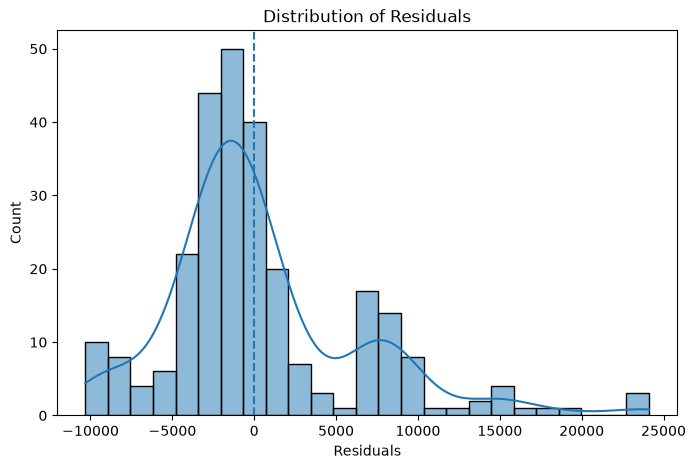

In [73]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.title("Distribution of Residuals")
plt.xlabel("Residuals")

plt.show()

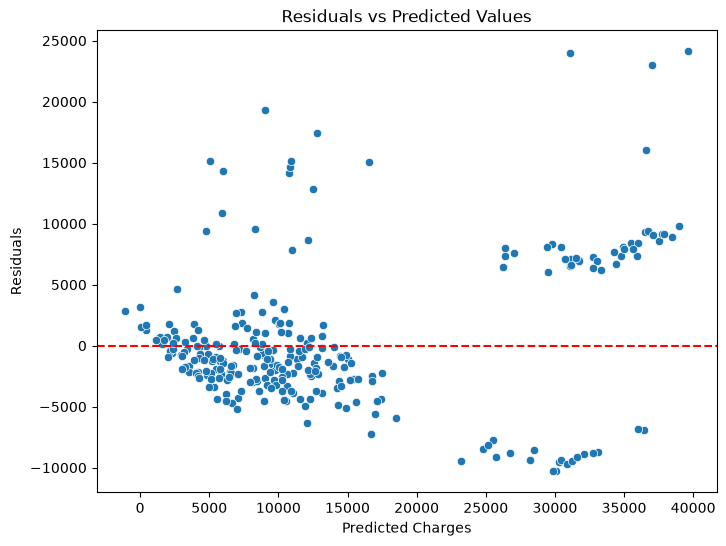

In [74]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

In [75]:
# there should not be a pattern.

# Q-Q plot

<Figure size 700x700 with 0 Axes>

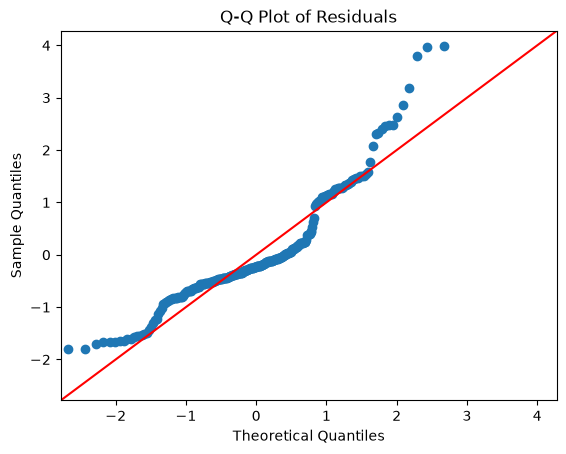

In [76]:
plt.figure(figsize=(7,7))

sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Q-Q Plot of Residuals")

plt.show()

In [77]:
# if the points are close to the line than the residuals are normal and if not,yeah.

# shapiro_wilk test

In [78]:
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("Statistic:", shapiro_stat)
print("P-value:", shapiro_p)

Statistic: 0.8977461569762878
P-value: 1.6968785612869801e-12


H0 → Residuals are normally distributed

H1 → Residuals are not normally distributed

# multicollinearity

In [79]:
X_vif = sm.add_constant(X)

In [80]:
vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif_data

,Feature,VIF
0,const,35.504594
1,age,1.016794
2,bmi,1.106742
3,children,1.004017
4,sex_male,1.008944
5,smoker_yes,1.012100
6,region_northwest,1.517673
7,region_southeast,1.651779
8,region_southwest,1.529044


> VIF	Meaning
> 
1	Excellent

1–5	Usually acceptable

5–10	Potential concern

>10	Serious concern

In [81]:
diagnostics = {
    "R2": ols_results.rsquared,
    "Adjusted R2": ols_results.rsquared_adj,
    "F-statistic": ols_results.fvalue,
    "F-test p-value": ols_results.f_pvalue,
    "AIC": ols_results.aic,
    "BIC": ols_results.bic
}

diagnostics

{'R2': np.float64(0.7299057809339075),
 'Adjusted R2': np.float64(0.7278673339975597),
 'F-statistic': np.float64(358.0695518332328),
 'F-test p-value': np.float64(4.936213126365937e-295),
 'AIC': np.float64(21679.960604098982),
 'BIC': np.float64(21724.73091429821)}

# Compare OLS With Regularized Models:
- OLS
- Ridge
- Lasso
- Elastic Net

In [82]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

# train

In [83]:
models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(
            mean_squared_error(y_test, predictions)
        ),
        "R²": r2_score(y_test, predictions)
    })

comparison = pd.DataFrame(results)

comparison

,Model,MAE,RMSE,R²
0,OLS,4177.045561,5956.342894,0.806929
1,Ridge,4194.009577,5971.338292,0.805955
2,Lasso,4177.130359,5956.451512,0.806922
3,Elastic Net,4972.931325,6932.656011,0.738448


# Compare Models Visually

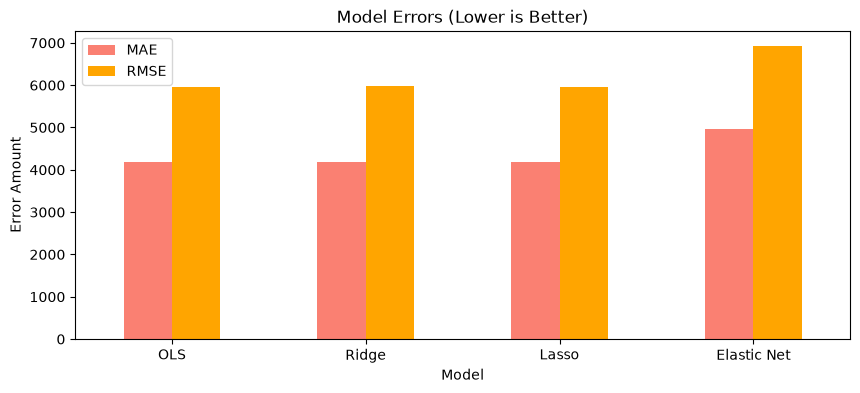

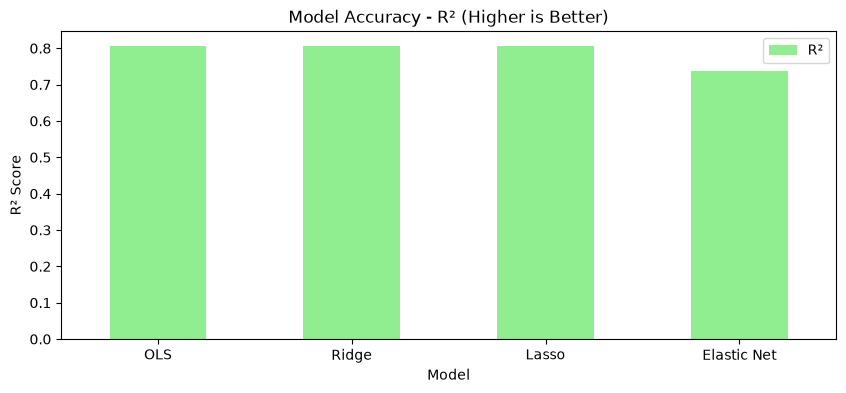

In [89]:
comparison.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar", figsize=(10,4), color=['salmon', 'orange']
)
plt.title("Model Errors (Lower is Better)")
plt.ylabel("Error Amount")
plt.xticks(rotation=0)
plt.show()

# Graph 2: Accuracy (R²)
comparison.set_index("Model")[["R²"]].plot(
    kind="bar", figsize=(10,4), color='lightgreen'
)
plt.title("Model Accuracy - R² (Higher is Better)")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.show()

# final coefficient table

In [85]:
coef_table = pd.DataFrame({
    "Coefficient": ols_results.params,
    "Std Error": ols_results.bse,
    "t-value": ols_results.tvalues,
    "P-value": ols_results.pvalues,
    "CI Lower": ols_results.conf_int()[0],
    "CI Upper": ols_results.conf_int()[1]
})

coef_table

,Coefficient,Std Error,t-value,P-value,CI Lower,CI Upper
const,-11092.652296,1114.260203,-9.955172,2.217550e-22,-13279.058670,-8906.245922
age,248.210720,13.507334,18.375996,1.103624e-65,221.706568,274.714872
bmi,318.701441,32.543377,9.793127,9.741389e-22,254.844680,382.558202
children,533.009989,156.796272,3.399379,7.005340e-04,225.343640,840.676338
sex_male,-101.542054,375.787277,-0.270212,7.870501e-01,-838.913537,635.829429
smoker_yes,23077.764593,471.029768,48.994281,1.383449e-274,22153.507868,24002.021318
region_northwest,-391.761455,537.999006,-0.728182,4.666627e-01,-1447.425521,663.902611
region_southeast,-838.919616,546.100555,-1.536200,1.247878e-01,-1910.480578,232.641346
region_southwest,-659.139752,539.458579,-1.221854,2.220344e-01,-1717.667798,399.388295


# Residual summary

In [86]:
residual_summary = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals
})

residual_summary.head(10)

,Actual,Predicted,Residual
900,8688.85885,8143.693884,545.164966
1064,5708.86700,5737.115683,-28.248683
1256,11436.73815,14369.314876,-2932.576726
298,38746.35510,31745.513636,7000.841464
237,4463.20510,8962.386657,-4499.181557
481,9304.70190,13149.722353,-3845.020453
240,38511.62830,30446.760679,8064.867621
277,2150.46900,1453.288813,697.180187
415,7345.72660,10633.018402,-3287.291802
707,10264.44210,11318.943794,-1054.501694


| Check                 | Purpose                             |
| --------------------- | ----------------------------------- |
| R²                    | Model explanatory power             |
| Adjusted R²           | Penalizes unnecessary predictors    |
| MAE                   | Average prediction error            |
| RMSE                  | Penalizes large errors              |
| Actual vs Predicted   | Prediction quality                  |
| Residual distribution | Error behavior                      |
| Residual vs Predicted | Linearity + variance patterns       |
| Q-Q plot              | Residual normality                  |
| Shapiro test          | Statistical normality check         |
| Breusch-Pagan         | Constant variance                   |
| VIF                   | Multicollinearity                   |
| Cook's Distance       | Influential observations            |
| p-values              | Individual coefficient significance |
| Confidence intervals  | Coefficient uncertainty             |
| F-test                | Overall model significance          |
| AIC/BIC               | Model comparison                    |


In [87]:
residual_summary.to_csv(
    "ols_predictions.csv",
    index=False
)